# AUTOMATED MEDICAL IMAGE DIAGNOSIS USING CNNs

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
df=pd.read_csv('Data_Entry_2017.csv')

In [3]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  object 
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(4), object(5)
memory usage: 10.3+ MB


### Data Cleaning and Label Formatting 

In [5]:
df["Patient Age"] = df["Patient Age"].str.extract('(\d+)').astype(int)


In [6]:
df=df.drop(columns=['Unnamed: 11'])

#### checking for duplicates

In [7]:
duplicates = df.duplicated(subset=['Image Index'])
print("True duplicate rows:", duplicates.sum())

# See them if any exist
if duplicates.sum() > 0:
    print(df[df.duplicated(subset=['Image Index'], keep=False)])

True duplicate rows: 0


#### How many images does each patient have?

In [8]:
imgs_per_patient = df.groupby('Patient ID').size().sort_values(ascending=False)

print("Top 5 patients with most images:")
print(imgs_per_patient.head())

print("\nPatients with only 1 image:", (imgs_per_patient == 1).sum())
print("Patients with 2-5 images:", ((imgs_per_patient >= 2) & (imgs_per_patient <= 5)).sum())
print("Patients with 6+ images:", (imgs_per_patient >= 6).sum())

Top 5 patients with most images:
Patient ID
10007    184
13670    173
15530    158
12834    157
13993    143
dtype: int64

Patients with only 1 image: 17503
Patients with 2-5 images: 8481
Patients with 6+ images: 4821


# EDA

## Count of thoracic diseases 

/var/folders/yg/_17071v52gj5ww0gzm_hb2bw0000gn/T/ipykernel_1206/281867586.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')


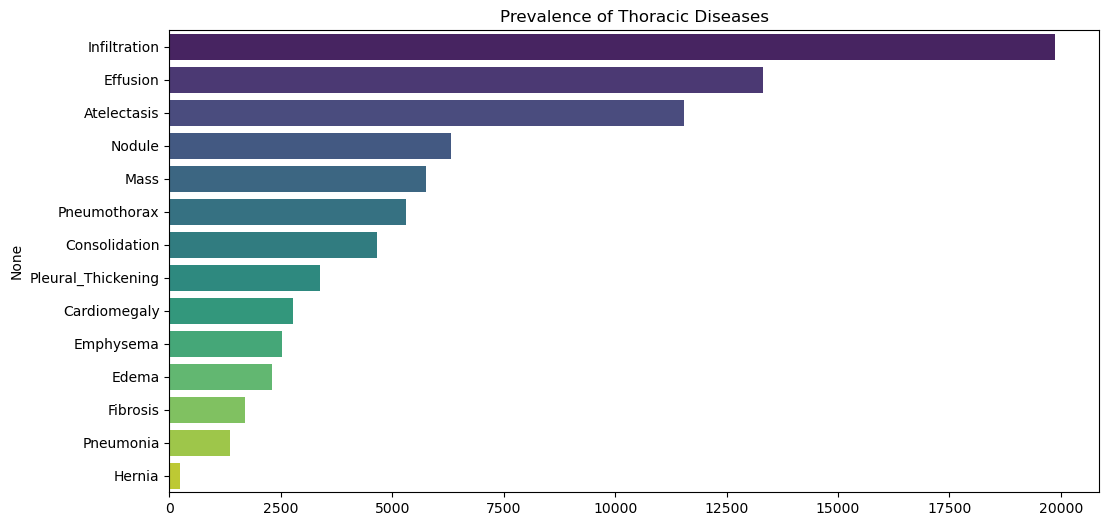

In [15]:
def run_chest_eda(df):
    label_counts = df[all_labels].sum().sort_values(ascending=False)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
    plt.title('Prevalence of Thoracic Diseases')
    plt.show()
run_chest_eda(df)

### Comparing Patients with Diseases and Non-Diseases 

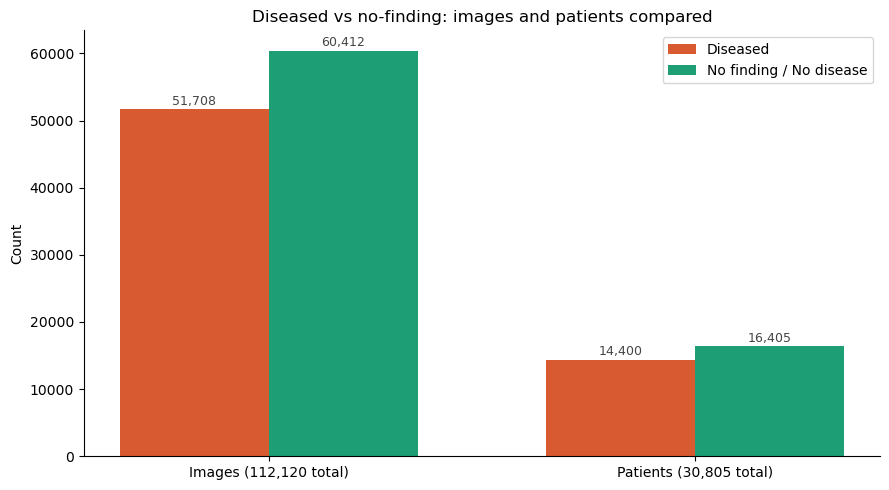

In [16]:

def add_bar_labels(ax, bars):
    for bar in bars:
        val = int(bar.get_height())
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}', ha='center', va='bottom', fontsize=9, color='#444')

# ── Plot: Grouped bar with labels
fig, ax = plt.subplots(figsize=(9, 5))
x = [0, 1]
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], [51708, 14400],
               width=width, color='#D85A30', label='Diseased', edgecolor='none')
bars2 = ax.bar([i + width/2 for i in x], [60412, 16405],
               width=width, color='#1D9E75', label='No finding / No disease', edgecolor='none')

add_bar_labels(ax, bars1)
add_bar_labels(ax, bars2)

ax.set_xticks(x)
ax.set_xticklabels(['Images (112,120 total)', 'Patients (30,805 total)'])
ax.set_ylabel('Count')
ax.set_title('Diseased vs no-finding: images and patients compared', fontsize=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

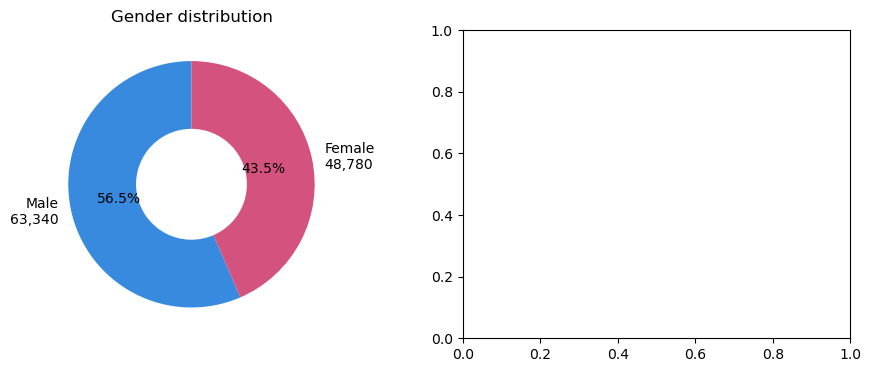

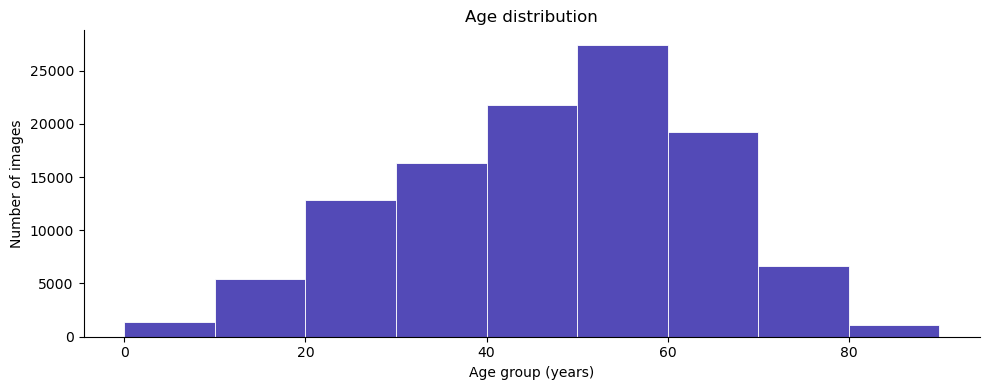

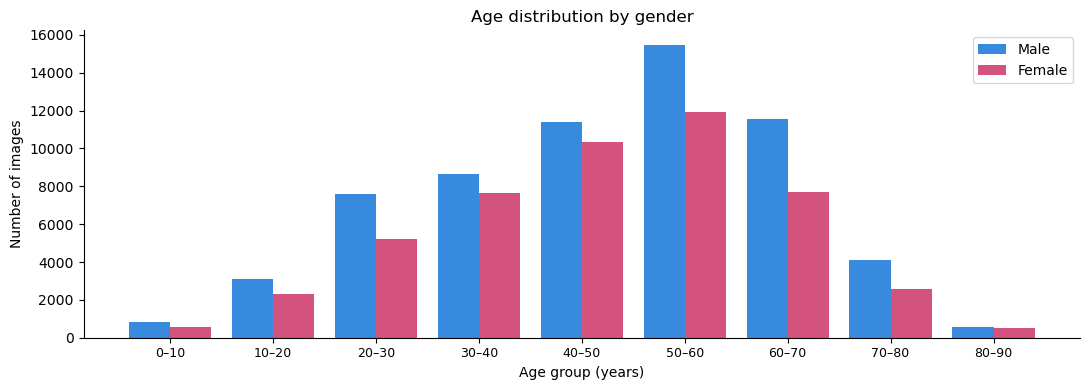

In [17]:
# ── CELL: Age & Gender Visualizations ────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Gender Donut
gender_counts = df['Patient Gender'].value_counts()
axes[0].pie(gender_counts,
            labels=[f'Male\n{gender_counts["M"]:,}', f'Female\n{gender_counts["F"]:,}'],
            autopct='%1.1f%%',
            colors=['#378ADD', '#D4537E'],
            startangle=90,
            wedgeprops=dict(width=0.55))
axes[0].set_title('Gender distribution', fontsize=12)

# ── Age Distribution (overall)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['Patient Age'], bins=range(0, 100, 10),
        color='#534AB7', edgecolor='white', linewidth=0.6)
ax.set_title('Age distribution', fontsize=12)
ax.set_xlabel('Age group (years)', fontsize=10)
ax.set_ylabel('Number of images', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── Age Distribution by Gender (grouped)
male_df   = df[df['Patient Gender'] == 'M']
female_df = df[df['Patient Gender'] == 'F']
bins = range(0, 100, 10)

male_counts,   bin_edges = np.histogram(male_df['Patient Age'],   bins=bins)
female_counts, _         = np.histogram(female_df['Patient Age'], bins=bins)

x = np.arange(len(male_counts))
width = 0.4

fig, ax = plt.subplots(figsize=(11, 4))
bars_m = ax.bar(x - width/2, male_counts,   width, color='#378ADD', label='Male',   edgecolor='none')
bars_f = ax.bar(x + width/2, female_counts, width, color='#D4537E', label='Female', edgecolor='none')

age_labels = [f'{i}–{i+10}' for i in range(0, 90, 10)]
ax.set_xticks(x)
ax.set_xticklabels(age_labels, fontsize=9)
ax.set_title('Age distribution by gender', fontsize=12)
ax.set_xlabel('Age group (years)', fontsize=10)
ax.set_ylabel('Number of images', fontsize=10)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [18]:
# --- FIXED LABEL ENCODING ---

all_labels = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
              'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
              'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
              'Pneumonia', 'Pneumothorax']

# Encode diseases safely
for label in all_labels:
    df[label] = df['Finding Labels'].apply(
        lambda x: 1 if label in x.split('|') else 0
    )

# Fix "No Finding"
df['No Finding'] = df['Finding Labels'].apply(
    lambda x: 1 if x.strip() == 'No Finding' else 0
)

###  Path mapping (Assuming all images are in one folder 'images_224')

In [19]:
image_dir = 'images-224'
if os.path.exists(image_dir):
    all_images = os.listdir(image_dir)
    print(f"Image folder found: {image_dir}")
    print(f"Total image files in folder: {len(all_images):,}")
    print(f"Sample files: {all_images[:5]}")
else:
    print(f"Folder '{image_dir}' NOT found — check your path!")

Image folder found: images-224
Total image files in folder: 112,120
Sample files: ['00018805_001.png', '00005868_002.png', '00009663_000.png', '00022156_007.png', '00005395_004.png']


In [20]:
df['image_path'] = df['Image Index'].apply(lambda x: os.path.join(image_dir, x))
df['image_exists'] = df['image_path'].apply(os.path.exists)
total = len(df)
found = df['image_exists'].sum()
missing = total - found
print(f"Total rows in CSV   : {total:,}")
print(f"Images found on disk: {found:,}")
print(f"Images missing      : {missing:,}")
print(f"Match rate          : {found/total*100:.1f}%")

Total rows in CSV   : 112,120
Images found on disk: 112,120
Images missing      : 0
Match rate          : 100.0%


In [21]:
df_mapped = df[df['image_exists'] == True].copy()
df_mapped.drop(columns=['image_exists'], inplace=True)

print(f"Dataset after mapping: {len(df_mapped):,} images ready to use")
print()
print("Sample mapped rows:")
print(df_mapped[['Image Index', 'image_path', 'Finding Labels']].head(5))

Dataset after mapping: 112,120 images ready to use

Sample mapped rows:
        Image Index                   image_path          Finding Labels
0  00000001_000.png  images-224/00000001_000.png            Cardiomegaly
1  00000001_001.png  images-224/00000001_001.png  Cardiomegaly|Emphysema
2  00000001_002.png  images-224/00000001_002.png   Cardiomegaly|Effusion
3  00000002_000.png  images-224/00000002_000.png              No Finding
4  00000003_000.png  images-224/00000003_000.png                  Hernia


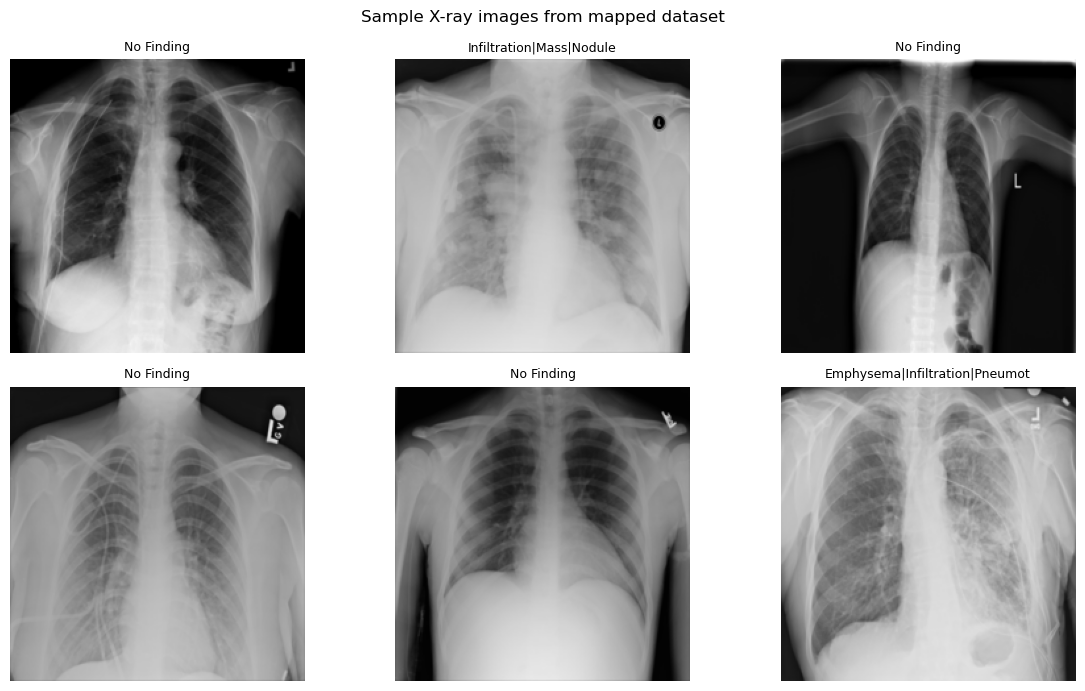

In [22]:
from PIL import Image
import matplotlib.pyplot as plt
import random

# Pick 6 random images and display them
sample_rows = df_mapped.sample(6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row['image_path']).convert('RGB')
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"{row['Finding Labels'][:30]}", fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample X-ray images from mapped dataset', fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
patient_ids = df_mapped['Patient ID'].unique()
train_ids, test_ids = train_test_split(
    patient_ids, test_size=0.2, random_state=42
)
patient_ids = df_mapped['Patient ID'].unique()

# Step 1 — split off test (20%) first
train_val_ids, test_ids = train_test_split(
    patient_ids, test_size=0.2, random_state=42
)

# Step 2 — split remaining 80% into train (70%) and val (10%)
train_ids, val_ids = train_test_split(
    train_val_ids, test_size=0.125, random_state=42
)

train_df = df_mapped[df_mapped['Patient ID'].isin(train_ids)].reset_index(drop=True)
val_df   = df_mapped[df_mapped['Patient ID'].isin(val_ids)].reset_index(drop=True)
test_df  = df_mapped[df_mapped['Patient ID'].isin(test_ids)].reset_index(drop=True)

print(f"Train — Patients: {len(train_ids):,} Images: {len(train_df):,}")
print(f"Validation — Patients: {len(val_ids):,} Images: {len(val_df):,}")
print(f"Test — Patients: {len(test_ids):,} Images: {len(test_df):,}")
print(f"Total Images: {len(train_df)+len(val_df)+len(test_df):,}")
train_df = df_mapped[df_mapped['Patient ID'].isin(train_ids)].reset_index(drop=True)
test_df = df_mapped[df_mapped['Patient ID'].isin(test_ids)].reset_index(drop=True)

print(f"Train —Patients: {len(train_ids):,} | Images: {len(train_df):,}")
print(f"Test — Patients: {len(test_ids):,} | Images: {len(test_df):,}")

Train — Patients: 21,563 Images: 78,614
Validation — Patients: 3,081 Images: 11,212
Test — Patients: 6,161 Images: 22,294
Total Images: 112,120
Train —Patients: 21,563 | Images: 78,614
Test — Patients: 6,161 | Images: 22,294


In [24]:
# ── CELL 6: Compute class weights for imbalance ───────────────────

import torch
import numpy as np

all_labels = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
              'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
              'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
              'Pneumonia', 'Pneumothorax']

label_counts = train_df[all_labels].sum()
total_train  = len(train_df)

# pos_weight = (negative samples) / (positive samples) per label
pos_weights = torch.tensor(
    [(total_train - count) / (count + 1e-5) for count in label_counts],
    dtype=torch.float32
)
pos_weights = torch.clamp(pos_weights, max=50)
print("Class weights (higher = rarer disease):")
for label, w in zip(all_labels, pos_weights):
    print(f"  {label:<20} {w:.2f}")

Class weights (higher = rarer disease):
  Atelectasis          8.69
  Cardiomegaly         40.22
  Consolidation        22.85
  Edema                48.95
  Effusion             7.28
  Emphysema            43.69
  Fibrosis             50.00
  Hernia               50.00
  Infiltration         4.72
  Mass                 18.08
  Nodule               16.50
  Pleural_Thickening   32.28
  Pneumonia            50.00
  Pneumothorax         19.56


In [25]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Train transform: resize + flip + rotate + jitter + normalize")
print("Test transform : resize + normalize only")

Train transform: resize + flip + rotate + jitter + normalize
Test transform : resize + normalize only


In [26]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
class NIH_Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        self.labels    = all_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row          = self.df.iloc[idx]
        image        = Image.open(row['image_path']).convert('RGB')
        label_vector = torch.tensor(
            row[self.labels].values.astype(np.float32)
        )
        if self.transform:
            image = self.transform(image)
        return image, label_vector

train_dataset = NIH_Dataset(train_df, transform=train_transform)
val_dataset   = NIH_Dataset(val_df,   transform=test_transform)  
test_dataset  = NIH_Dataset(test_df,  transform=test_transform)  

train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches     : {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches      : {len(test_loader)}")

Train batches     : 2457
Validation batches: 351
Test batches      : 697


In [27]:
# ── CELL 10: Sanity check ─────────────────────────────────────────
images, labels = next(iter(train_loader))

print(f"Image batch shape : {images.shape}")
# expected → torch.Size([32, 3, 224, 224])

print(f"Label batch shape : {labels.shape}")
# expected → torch.Size([32, 14])

print(f"Pixel range       : {images.min():.2f} to {images.max():.2f}")
print(f"Label sample      : {labels[0]}")

Image batch shape : torch.Size([32, 3, 224, 224])
Label batch shape : torch.Size([32, 14])
Pixel range       : -2.12 to 2.64
Label sample      : tensor([0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [45]:

import torch.nn as nn
from torchvision import models

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available()
                      else 'cpu')
print(f"Device: {device}")

model = models.densenet121(weights='IMAGENET1K_V1')
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, len(all_labels))
model = model.to(device)

print(f"DenseNet121 ready — output: {in_features} → {len(all_labels)}")

Device: mps
DenseNet121 ready — output: 1024 → 14


In [46]:

print(f"{'Disease':<22} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 52)
for label in all_labels:
    t  = train_df[label].sum()
    v  = val_df[label].sum()
    te = test_df[label].sum()
    flag = "  ⚠️" if v < 10 or te < 10 else ""
    print(f"  {label:<20} {t:>8,} {v:>8,} {te:>8,}{flag}")

Disease                   Train      Val     Test
----------------------------------------------------
  Atelectasis             8,112    1,220    2,203
  Cardiomegaly            1,907      247      618
  Consolidation           3,296      420      951
  Edema                   1,574      275      454
  Effusion                9,490    1,267    2,550
  Emphysema               1,759      226      531
  Fibrosis                1,164      158      364
  Hernia                    150       29       48
  Infiltration           13,736    2,040    4,094
  Mass                    4,121      556    1,069
  Nodule                  4,492      551    1,280
  Pleural_Thickening      2,362      363      660
  Pneumonia                 922      151      280
  Pneumothorax            3,823      456    1,019


In [47]:

from torch.utils.data import WeightedRandomSampler

def compute_sample_weights(dataframe, labels):
    label_counts  = dataframe[labels].sum()
    label_weights = 1.0 / (label_counts + 1e-5)
    sample_weights = []
    for _, row in dataframe.iterrows():
        label_vec = row[labels].values
        if label_vec.sum() == 0:
            sample_weights.append(float(label_weights.min()))
        else:
            weight = float((label_vec * label_weights.values).max())
            sample_weights.append(weight)
    return torch.tensor(sample_weights, dtype=torch.float32)

sample_weights = compute_sample_weights(train_df, all_labels)
print(f"Done — {len(sample_weights):,} sample weights computed")

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
print("WeightedRandomSampler ready ✅")


Done — 78,614 sample weights computed
WeightedRandomSampler ready ✅


In [48]:

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,       
    num_workers=0,
    pin_memory=False
)

val_loader  = DataLoader(val_dataset,  batch_size=32,
                         shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32,
                         shuffle=False, num_workers=0, pin_memory=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("train_loader now uses WeightedRandomSampler ✅")

Train batches : 2457
Val batches   : 351
Test batches  : 697
train_loader now uses WeightedRandomSampler ✅


In [43]:

import gc
gc.collect()
torch.mps.empty_cache()

# Check how much memory is being used
print(f"MPS memory allocated: {torch.mps.current_allocated_memory() / 1024**2:.1f} MB")
print(f"MPS memory reserved : {torch.mps.driver_allocated_memory() / 1024**2:.1f} MB")

MPS memory allocated: 547.4 MB
MPS memory reserved : 3258.8 MB


In [ ]:

import torch.optim as optim
import matplotlib.pyplot as plt

criterion     = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))
optimizer     = optim.Adam(model.parameters(), lr=1e-4)

NUM_EPOCHS    = 5
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

for epoch in range(NUM_EPOCHS):

    # Train
    model.train()
    running_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validate
    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            running_val += criterion(model(imgs), lbls).item()
    val_loss = running_val / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  --> Best model saved")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses,
         label='Train Loss', color='#378ADD', marker='o')
plt.plot(range(1, NUM_EPOCHS+1), val_losses,
         label='Val Loss',   color='#D85A30', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [50]:

from sklearn.metrics import roc_auc_score
import gc

model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds, all_true = [], []

with torch.no_grad():
    for step, (imgs, lbls) in enumerate(test_loader):
        imgs    = imgs.to(device)
        outputs = torch.sigmoid(model(imgs))
        all_preds.append(outputs.cpu().numpy())
        all_true.append(lbls.numpy())

        # Clear memory every 50 steps
        if step % 50 == 0:
            gc.collect()
            torch.mps.empty_cache()

all_preds = np.vstack(all_preds)
all_true  = np.vstack(all_true)

print(f"{'Disease':<22} {'AUC-ROC':>8}")
print("-" * 33)
auc_scores = []
for i, label in enumerate(all_labels):
    try:
        auc = roc_auc_score(all_true[:, i], all_preds[:, i])
        auc_scores.append(auc)
        print(f"  {label:<20} {auc:.4f}")
    except:
        auc_scores.append(0)
        print(f"  {label:<20}      N/A")

print("-" * 33)
print(f"  {'Mean AUC':<20} {np.mean(auc_scores):.4f}")

Disease                 AUC-ROC
---------------------------------
  Atelectasis          0.7438
  Cardiomegaly         0.8593
  Consolidation        0.7795
  Edema                0.8667
  Effusion             0.8205
  Emphysema            0.8567
  Fibrosis             0.7313
  Hernia               0.8691
  Infiltration         0.6714
  Mass                 0.7006
  Nodule               0.6483
  Pleural_Thickening   0.7270
  Pneumonia            0.6826
  Pneumothorax         0.8183
---------------------------------
  Mean AUC             0.7697


## CHECK FOR ABOUT TRAINING LOOP, IF IT DOESN'T GIVE YOU ANY OUTPUT JUST TRY WITH THIS BELOW CODE 

  Epoch 1 | Step 0/300 | Loss: 3.4379
  Epoch 1 | Step 100/300 | Loss: 1.6054
  Epoch 1 | Step 200/300 | Loss: 1.6402

Epoch [1/3]  Train Loss: 1.7684  Val Loss: 1.2718
  --> Best model saved (val loss: 1.2718)

  Epoch 2 | Step 0/300 | Loss: 1.5125
  Epoch 2 | Step 100/300 | Loss: 1.6346
  Epoch 2 | Step 200/300 | Loss: 1.3826

Epoch [2/3]  Train Loss: 1.5992  Val Loss: 1.1583
  --> Best model saved (val loss: 1.1583)

  Epoch 3 | Step 0/300 | Loss: 1.6046
  Epoch 3 | Step 100/300 | Loss: 1.4580
  Epoch 3 | Step 200/300 | Loss: 1.5019

Epoch [3/3]  Train Loss: 1.5240  Val Loss: 1.1239
  --> Best model saved (val loss: 1.1239)

Training complete!


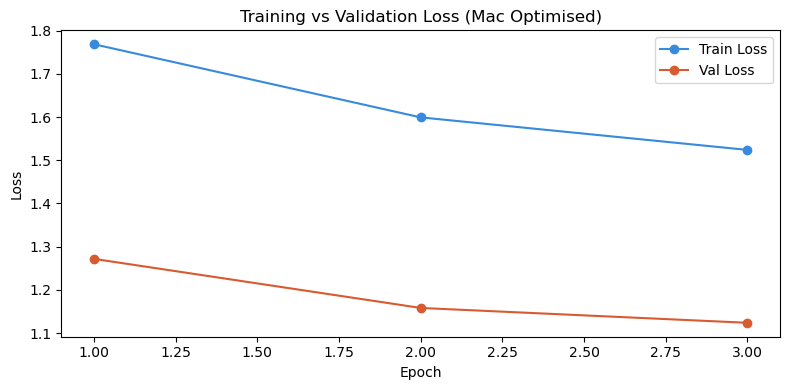

In [49]:
# ── CELL 15 (MAC OPTIMISED): Training loop ────────────────────────
import torch.optim as optim
import matplotlib.pyplot as plt
import gc

# ── Rebuild loaders with smaller batch size for Mac
train_loader_mac = DataLoader(
    train_dataset,
    batch_size=16,         # ← reduced from 32
    sampler=sampler,
    num_workers=0,
    pin_memory=False
)
val_loader_mac = DataLoader(
    val_dataset,
    batch_size=16,         # ← reduced from 32
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))
optimizer  = optim.Adam(model.parameters(), lr=1e-4)

NUM_EPOCHS       = 3       # ← reduced from 5
MAX_TRAIN_STEPS  = 300     # ← only 300 batches per epoch, not all 2457
best_val_loss    = float('inf')
train_losses     = []
val_losses       = []

for epoch in range(NUM_EPOCHS):

    # ── Train phase
    model.train()
    running_loss = 0.0
    for step, (imgs, lbls) in enumerate(train_loader_mac):

        if step >= MAX_TRAIN_STEPS:
            break                          # stop after 300 steps

        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # Clear memory every 50 steps
        if step % 50 == 0:
            gc.collect()
            if device.type == 'mps':
                torch.mps.empty_cache()

        # Print progress every 100 steps
        if step % 100 == 0:
            print(f"  Epoch {epoch+1} | Step {step}/{MAX_TRAIN_STEPS} "
                  f"| Loss: {loss.item():.4f}")

    train_loss = running_loss / MAX_TRAIN_STEPS
    train_losses.append(train_loss)

    # ── Validation phase
    model.eval()
    running_val = 0.0
    MAX_VAL_STEPS = 100    # limit val steps too
    with torch.no_grad():
        for step, (imgs, lbls) in enumerate(val_loader_mac):
            if step >= MAX_VAL_STEPS:
                break
            imgs, lbls = imgs.to(device), lbls.to(device)
            running_val += criterion(model(imgs), lbls).item()

    val_loss = running_val / MAX_VAL_STEPS
    val_losses.append(val_loss)

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  --> Best model saved (val loss: {best_val_loss:.4f})\n")

    # Force memory clear after each epoch
    gc.collect()
    if device.type == 'mps':
        torch.mps.empty_cache()

print("Training complete!")

# ── Plot loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses,
         label='Train Loss', color='#378ADD', marker='o')
plt.plot(range(1, NUM_EPOCHS+1), val_losses,
         label='Val Loss',   color='#D85A30', marker='o')
plt.title('Training vs Validation Loss (Mac Optimised)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# ── ResNet50 Comparison ───────────────────────────────────────────
import gc
from torchvision import models

# Clear memory from previous model
del model
gc.collect()
torch.mps.empty_cache()

# Load ResNet50
model_resnet = models.resnet50(weights='IMAGENET1K_V1')
in_features  = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(in_features, len(all_labels))
model_resnet = model_resnet.to(device)
print(f"ResNet50 ready — output: {in_features} → {len(all_labels)}")

ResNet50 ready — output: 2048 → 14


In [36]:
# ── Train ResNet50 ────────────────────────────────────────────────
import torch.optim as optim

criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))
optimizer  = optim.Adam(model_resnet.parameters(), lr=1e-4)

NUM_EPOCHS = 3
MAX_STEPS  = 300
best_val   = float('inf')
train_losses_resnet = []
val_losses_resnet   = []

for epoch in range(NUM_EPOCHS):

    # Train
    model_resnet.train()
    running_loss = 0.0
    for step, (imgs, lbls) in enumerate(train_loader):
        if step >= MAX_STEPS: break
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model_resnet(imgs), lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if step % 50 == 0:
            gc.collect()
            torch.mps.empty_cache()

    train_loss = running_loss / MAX_STEPS
    train_losses_resnet.append(train_loss)

    # Validate
    model_resnet.eval()
    running_val = 0.0
    with torch.no_grad():
        for step, (imgs, lbls) in enumerate(val_loader):
            if step >= 100: break
            imgs, lbls = imgs.to(device), lbls.to(device)
            running_val += criterion(model_resnet(imgs), lbls).item()

    val_loss = running_val / 100
    val_losses_resnet.append(val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Train: {train_loss:.4f}  Val: {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_resnet.state_dict(), 'best_resnet50.pth')
        print(f"  --> Best ResNet50 saved")

    gc.collect()
    torch.mps.empty_cache()

print("ResNet50 training complete!")


Epoch [1/3]  Train: 1.5113  Val: 1.1143
  --> Best ResNet50 saved
Epoch [2/3]  Train: 1.4516  Val: 1.1532
Epoch [3/3]  Train: 1.3821  Val: 1.0416
  --> Best ResNet50 saved
ResNet50 training complete!


In [40]:
# ── Evaluate ResNet50 (fixed) ─────────────────────────────────────
from sklearn.metrics import roc_auc_score  # ← missing import

model_resnet.load_state_dict(torch.load('best_resnet50.pth', map_location=device))
model_resnet.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for step, (imgs, lbls) in enumerate(test_loader):
        imgs    = imgs.to(device)
        outputs = torch.sigmoid(model_resnet(imgs))
        all_preds.append(outputs.cpu().numpy())
        all_true.append(lbls.numpy())
        if step % 50 == 0:
            gc.collect()
            torch.mps.empty_cache()

all_preds = np.vstack(all_preds)
all_true  = np.vstack(all_true)

print(f"{'Disease':<22} {'AUC-ROC':>8}")
print("-" * 33)
resnet_aucs = []
for i, label in enumerate(all_labels):
    try:
        auc = roc_auc_score(all_true[:, i], all_preds[:, i])
        resnet_aucs.append(auc)
        print(f"  {label:<20} {auc:.4f}")
    except Exception as e:
        resnet_aucs.append(0)
        print(f"  {label:<20}  ERROR: {e}")
print("-" * 33)
print(f"  {'Mean AUC':<20} {np.mean(resnet_aucs):.4f}")

Disease                 AUC-ROC
---------------------------------
  Atelectasis          0.7476
  Cardiomegaly         0.8766
  Consolidation        0.7801
  Edema                0.8578
  Effusion             0.8454
  Emphysema            0.8783
  Fibrosis             0.7629
  Hernia               0.8872
  Infiltration         0.6588
  Mass                 0.7466
  Nodule               0.6243
  Pleural_Thickening   0.7614
  Pneumonia            0.6868
  Pneumothorax         0.8350
---------------------------------
  Mean AUC             0.7821
